In [5]:
import numpy as np
S_0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 1

In [6]:
n_runs=100
results = []
for N in [100,1000,10000,100000]:
    prices = []
    for i in range(n_runs):
        Z=np.random.normal(0,1,N)
        ST=S_0*np.exp((r-(sigma**2)/2)*T+sigma*np.sqrt(T)*Z)
        payoff=np.maximum(0,ST-K)
        payoff_mean=np.mean(payoff)
        C=payoff_mean*np.exp(-r*T)
        prices.append(C)
    print(N,np.mean(prices),np.std(prices))
    results.append({
        "N": N,
        "mean_price": np.mean(prices),
        "std_price": np.std(prices)
    })

100 10.450487609339485 1.406531000353624
1000 10.319397039018945 0.4611339284436823
10000 10.454138521215643 0.16142061862260232
100000 10.44979246694593 0.0542317452474941


In [7]:
import pandas as pd
df = pd.DataFrame(results)
df

,N,mean_price,std_price
0,100,10.450488,1.406531
1,1000,10.319397,0.461134
2,10000,10.454139,0.161421
3,100000,10.449792,0.054232


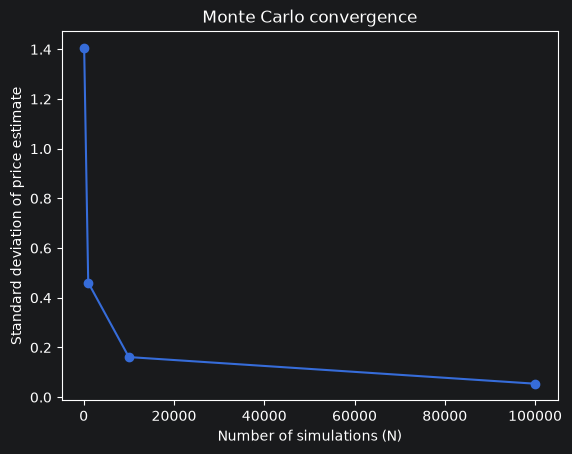

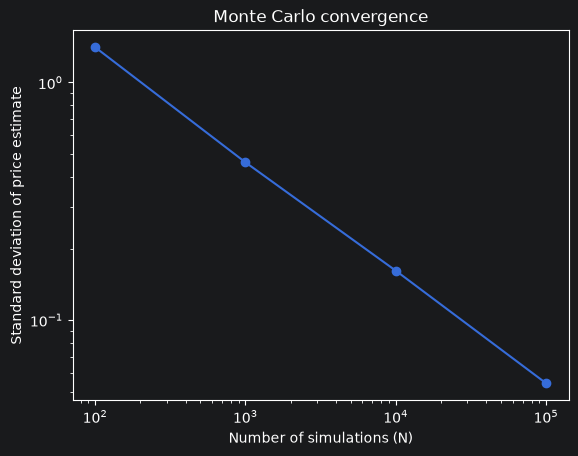

In [8]:
import matplotlib.pyplot as plt
plt.plot(df["N"], df["std_price"], marker="o")
plt.xlabel("Number of simulations (N)")
plt.ylabel("Standard deviation of price estimate")
plt.title("Monte Carlo convergence")
plt.show()
plt.loglog(df["N"], df["std_price"], marker="o")
plt.xlabel("Number of simulations (N)")
plt.ylabel("Standard deviation of price estimate")
plt.title("Monte Carlo convergence")
plt.show()

In [9]:
x = np.log(df["N"])
y = np.log(df["std_price"])

slope, intercept = np.polyfit(x, y, 1)

print("Estimated convergence rate:", slope)

Estimated convergence rate: -0.4697555253046661


In [10]:
from src.black_scholes import call_price
bs_price = call_price(S_0, K, r, sigma, T)
print("Black-Scholes price:", bs_price)

10.450583572185565
Black-Scholes price: 10.450583572185565


In [11]:
df["error"] = abs(df["mean_price"] - bs_price)
df["percentage_error"] = df["error"] / bs_price * 100
df

,N,mean_price,std_price,error,percentage_error
0,100,10.450488,1.406531,0.000096,0.000918
1,1000,10.319397,0.461134,0.131187,1.255303
2,10000,10.454139,0.161421,0.003555,0.034017
3,100000,10.449792,0.054232,0.000791,0.007570


In [23]:
results_ci = []
for N in [100,1000,10000,100000]:
    Z=np.random.normal(0,1,N)
    ST=S_0*np.exp((r-(sigma**2)/2)*T+sigma*np.sqrt(T)*Z)
    payoff=np.maximum(0,ST-K)
    payoff_mean=np.mean(payoff)
    payoff_std=np.std(payoff,ddof=1)
    prices=payoff_mean*np.exp(-r*T)
    standard_error = np.exp(-r * T) * payoff_std / np.sqrt(N)
    lower = prices - 1.96 * standard_error
    upper = prices + 1.96 * standard_error
    print(N,prices,standard_error,lower,upper)
    results_ci.append({
        "N": N,
        "monte_carlo_price": prices,
        "standard_error": standard_error,
        "lower_confidence_interval": lower,
        "upper_confidence_interval": upper
    })

100 9.986805495620498 1.3039850257018577 7.430994845244857 12.542616145996138
1000 9.87418838209768 0.44316886074502865 9.005577415037424 10.742799349157936
10000 10.655189890779566 0.14727745563800776 10.36652607772907 10.943853703830062
100000 10.436496193843366 0.0465263625443175 10.345304523256504 10.527687864430229


In [24]:
df_ci = pd.DataFrame(results_ci)
df_ci

,N,monte_carlo_price,standard_error,lower_confidence_interval,upper_confidence_interval
0,100,9.986805,1.303985,7.430995,12.542616
1,1000,9.874188,0.443169,9.005577,10.742799
2,10000,10.655190,0.147277,10.366526,10.943854
3,100000,10.436496,0.046526,10.345305,10.527688


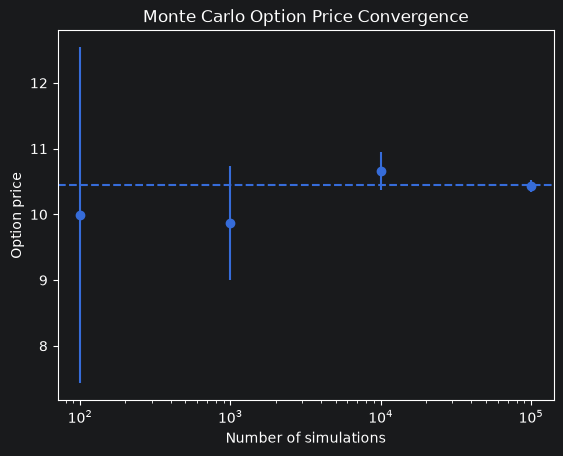

In [25]:
plt.errorbar(
    df_ci["N"],
    df_ci["monte_carlo_price"],
    yerr=1.96 * df_ci["standard_error"],
    fmt="o"
)

plt.axhline(bs_price, linestyle="--")

plt.xscale("log")
plt.xlabel("Number of simulations")
plt.ylabel("Option price")
plt.title("Monte Carlo Option Price Convergence")
plt.show()